In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent / "src") if '__file__' in dir() else 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from config import POPULARITY_THRESHOLD, KAGGLE_DATA_FILE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Setup complete!")

Setup complete!


In [2]:
import os
print(os.getcwd())

df_raw = pd.read_csv(KAGGLE_DATA_FILE)
df = df_raw[df_raw['track_genre'] == 'hip-hop'].copy()
df = df.reset_index(drop=True)

df['is_hit'] = (df['popularity'] >= POPULARITY_THRESHOLD).astype(int)
df['duration_sec'] = (df['duration_ms'] / 1000).round(1)
df['explicit'] = df['explicit'].astype(int)

print(f'Total hip-hop tracks: {len(df)}')
print(f'Hit rate: {df["is_hit"].mean():.1%}')
print(f'Hit vs Non-Hit: {df["is_hit"].value_counts().to_dict()}')
df.head()

/Users/snakeeeee/Desktop/dsci510_spring2026_final_project
Total hip-hop tracks: 1000
Hit rate: 57.2%
Hit vs Non-Hit: {1: 572, 0: 428}


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit,duration_sec
0,51000,1aL9518P5G72N92b48tuKw,AP Dhillon,Summer High,Summer High,83,177391,0,0.860,0.541,...,0.0325,0.16500,0.163000,0.0663,0.952,114.984,4,hip-hop,1,177.4
1,51001,08Isz2ETWSBhvIl8UpKYsp,Shubh,No Love,No Love,83,170387,0,0.768,0.487,...,0.0431,0.24000,0.000000,0.1750,0.722,137.034,4,hip-hop,1,170.4
2,51002,42TMa2hgBNjte4uV7jNCnQ,Shubh;Ikky,Baller,Baller,82,148188,0,0.711,0.702,...,0.2330,0.00487,0.016300,0.0932,0.674,180.219,4,hip-hop,1,148.2
3,51003,3UhmuWcFaLS3AO3kI9ynQ2,AP Dhillon;Shinda Kahlon;Gurinder Gill;Gminxr,Insane,Insane,77,206060,0,0.796,0.572,...,0.0545,0.41600,0.000025,0.0975,0.304,98.967,4,hip-hop,1,206.1
4,51004,5HCyWlXZPP0y6Gqq8TgA20,The Kid LAROI;Justin Bieber,STAY (with Justin Bieber),STAY (with Justin Bieber),89,141805,1,0.591,0.764,...,0.0483,0.03830,0.000000,0.1030,0.478,169.928,4,hip-hop,1,141.8


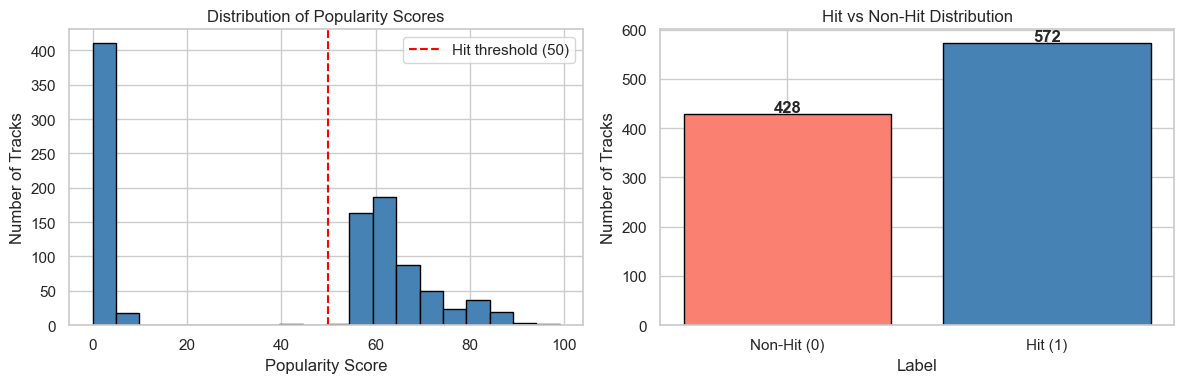

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['popularity'], bins=20, color='steelblue', edgecolor='black')
axes[0].axvline(x=POPULARITY_THRESHOLD, color='red', linestyle='--',
                label=f'Hit threshold ({POPULARITY_THRESHOLD})')
axes[0].set_title('Distribution of Popularity Scores')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Number of Tracks')
axes[0].legend()

hit_counts = df['is_hit'].value_counts()
axes[1].bar(['Non-Hit (0)', 'Hit (1)'],
            [hit_counts[0], hit_counts[1]],
            color=['salmon', 'steelblue'], edgecolor='black')
axes[1].set_title('Hit vs Non-Hit Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Number of Tracks')
for i, v in enumerate([hit_counts[0], hit_counts[1]]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

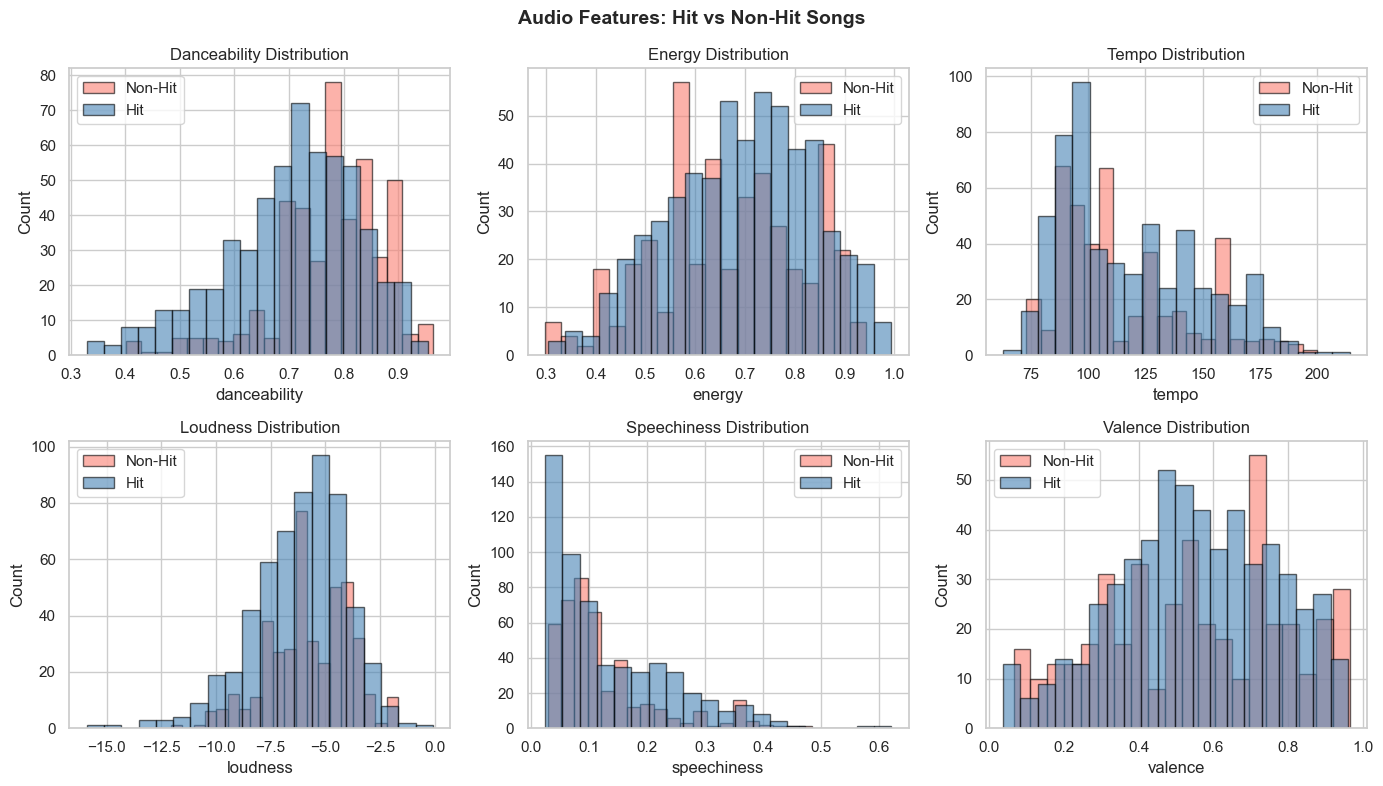

In [4]:
features = ['danceability', 'energy', 'tempo', 'loudness',
            'speechiness', 'valence']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    hits = df[df['is_hit'] == 1][feat]
    non_hits = df[df['is_hit'] == 0][feat]
    axes[i].hist(non_hits, bins=20, alpha=0.6, color='salmon',
                 label='Non-Hit', edgecolor='black')
    axes[i].hist(hits, bins=20, alpha=0.6, color='steelblue',
                 label='Hit', edgecolor='black')
    axes[i].set_title(f'{feat.capitalize()} Distribution')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Audio Features: Hit vs Non-Hit Songs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

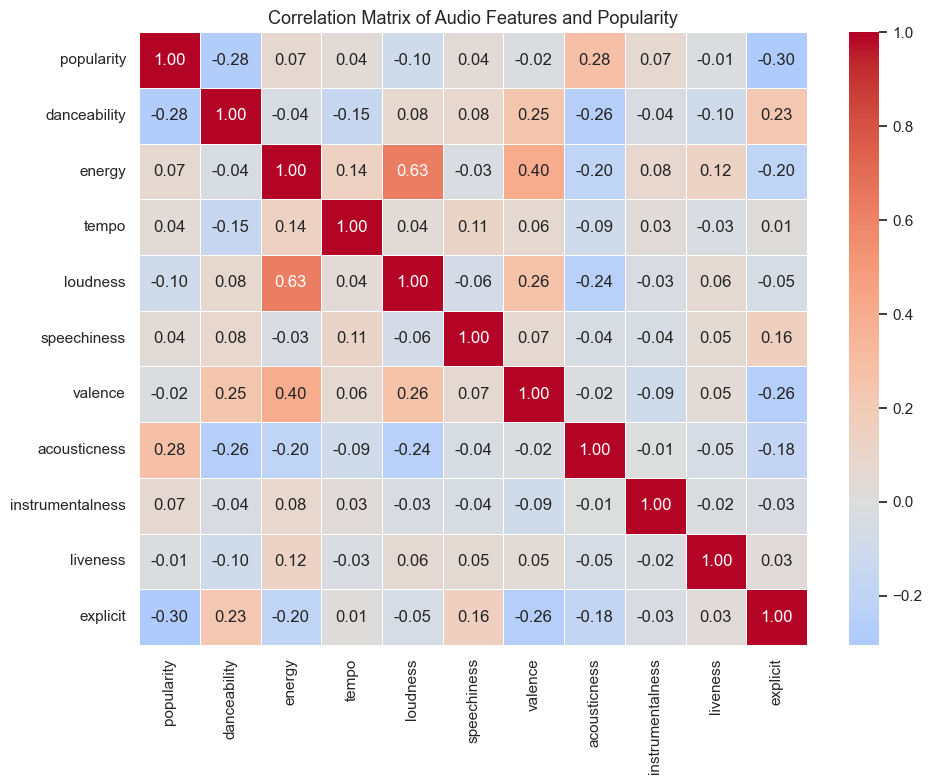

Top correlations with popularity:
acousticness        0.280
instrumentalness    0.072
energy              0.068
tempo               0.037
speechiness         0.036
liveness           -0.009
valence            -0.022
loudness           -0.099
danceability       -0.275
explicit           -0.304
Name: popularity, dtype: float64


In [5]:
corr_cols = ['popularity', 'danceability', 'energy', 'tempo',
             'loudness', 'speechiness', 'valence', 'acousticness',
             'instrumentalness', 'liveness', 'explicit']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Correlation Matrix of Audio Features and Popularity', fontsize=13)
plt.tight_layout()
plt.show()

print('Top correlations with popularity:')
print(corr_matrix['popularity'].drop('popularity').sort_values(
    ascending=False).round(3))

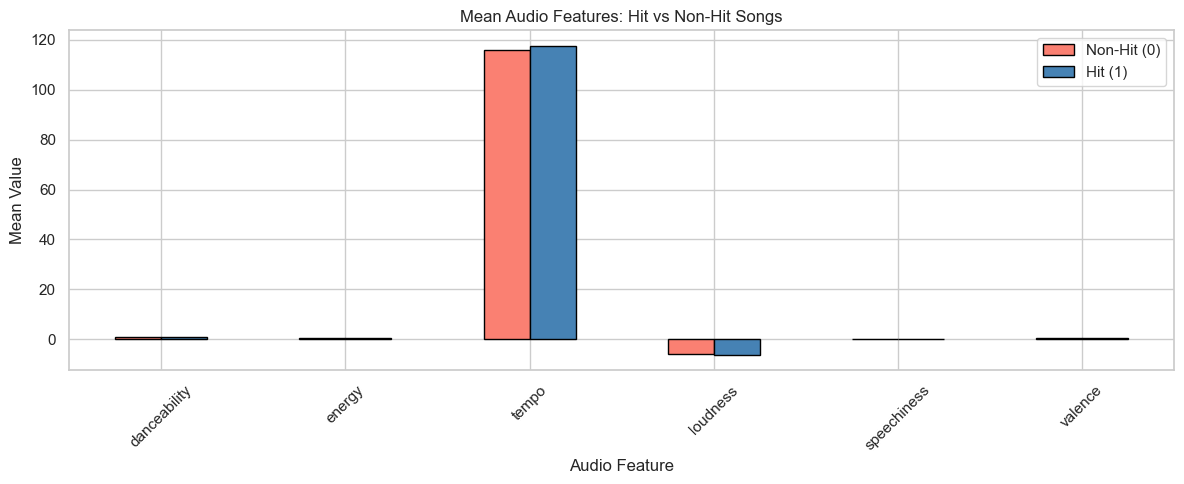

        danceability  energy    tempo  loudness  speechiness  valence
is_hit                                                               
0              0.778   0.667  115.721    -5.745        0.125    0.553
1              0.705   0.694  117.554    -6.158        0.134    0.550


In [6]:
feature_means = df.groupby('is_hit')[features].mean()

feature_means.T.plot(kind='bar', figsize=(12, 5),
                     color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Mean Audio Features: Hit vs Non-Hit Songs')
plt.xlabel('Audio Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(['Non-Hit (0)', 'Hit (1)'])
plt.tight_layout()
plt.show()

print(feature_means.round(3))

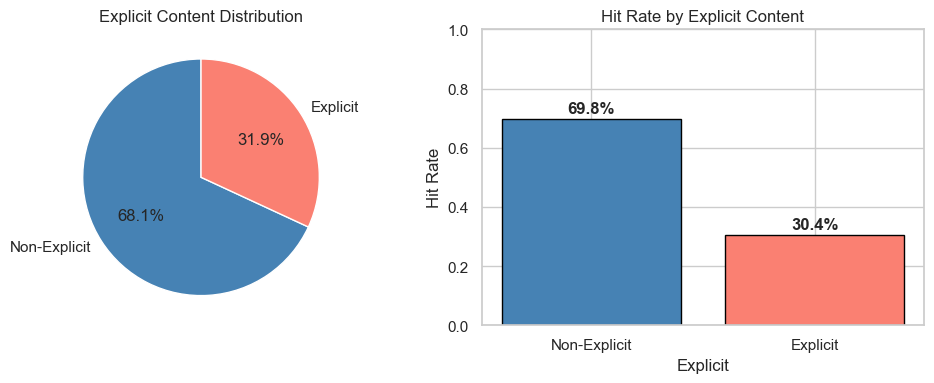

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

explicit_counts = df['explicit'].value_counts()
axes[0].pie(explicit_counts,
            labels=['Non-Explicit', 'Explicit'],
            autopct='%1.1f%%',
            colors=['steelblue', 'salmon'],
            startangle=90)
axes[0].set_title('Explicit Content Distribution')

hit_by_explicit = df.groupby('explicit')['is_hit'].mean()
axes[1].bar(['Non-Explicit', 'Explicit'],
            hit_by_explicit.values,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Hit Rate by Explicit Content')
axes[1].set_xlabel('Explicit')
axes[1].set_ylabel('Hit Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(hit_by_explicit.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
FEATURES = ['danceability', 'energy', 'tempo', 'loudness',
            'speechiness', 'valence', 'acousticness',
            'instrumentalness', 'liveness', 'explicit']

X = df[FEATURES]
y = df['is_hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set: 800 samples
Test set:     200 samples


In [9]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.3f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Non-Hit', 'Hit']))

=== Logistic Regression ===
Accuracy:  0.685
Precision: 0.692
Recall:    0.807
F1 Score:  0.745

              precision    recall  f1-score   support

     Non-Hit       0.67      0.52      0.59        86
         Hit       0.69      0.81      0.74       114

    accuracy                           0.69       200
   macro avg       0.68      0.67      0.67       200
weighted avg       0.68      0.69      0.68       200



In [10]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_dt):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_dt):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_dt):.3f}')
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Non-Hit', 'Hit']))

=== Decision Tree ===
Accuracy:  0.770
Precision: 0.821
Recall:    0.763
F1 Score:  0.791

              precision    recall  f1-score   support

     Non-Hit       0.71      0.78      0.74        86
         Hit       0.82      0.76      0.79       114

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



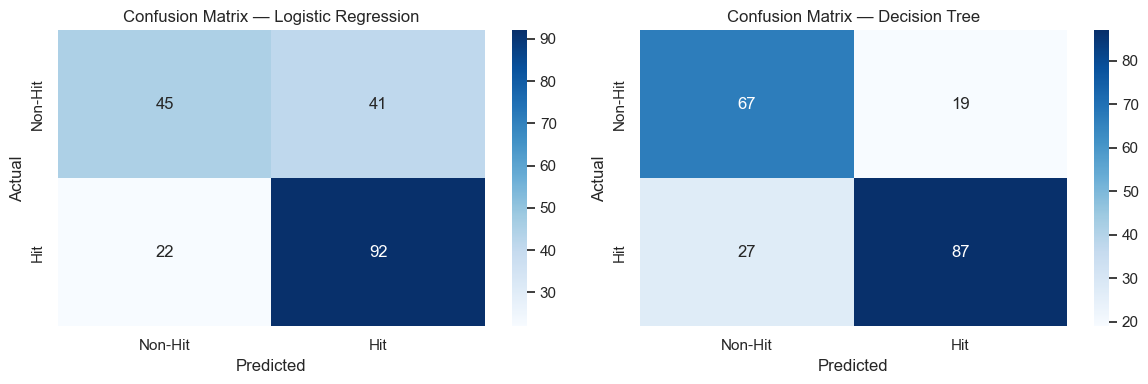

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Hit', 'Hit'],
                yticklabels=['Non-Hit', 'Hit'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

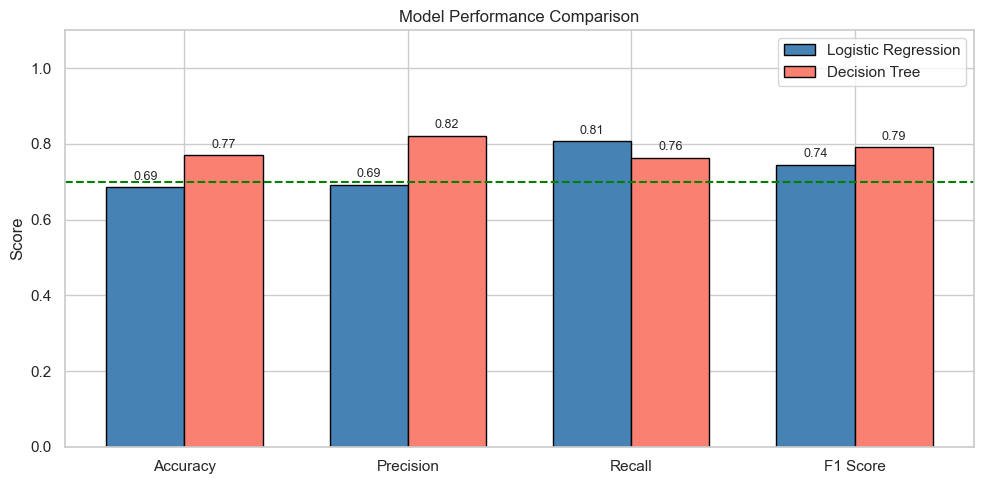

In [12]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], lr_scores, width,
               label='Logistic Regression', color='steelblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], dt_scores, width,
               label='Decision Tree', color='salmon', edgecolor='black')

ax.set_title('Model Performance Comparison')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.7, color='green', linestyle='--', label='Target (0.70)')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

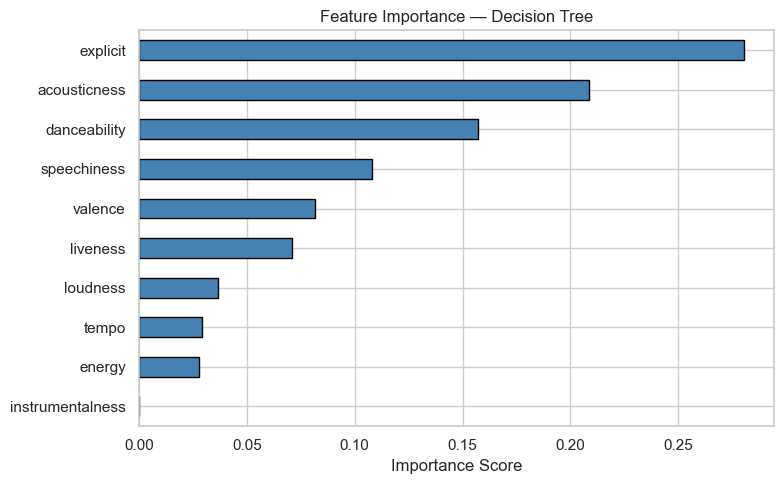

Top 3 most important features:
explicit        0.280410
acousticness    0.208571
danceability    0.157269
dtype: float64


In [13]:
importances = pd.Series(dt.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
print(importances.sort_values(ascending=False).head(3))

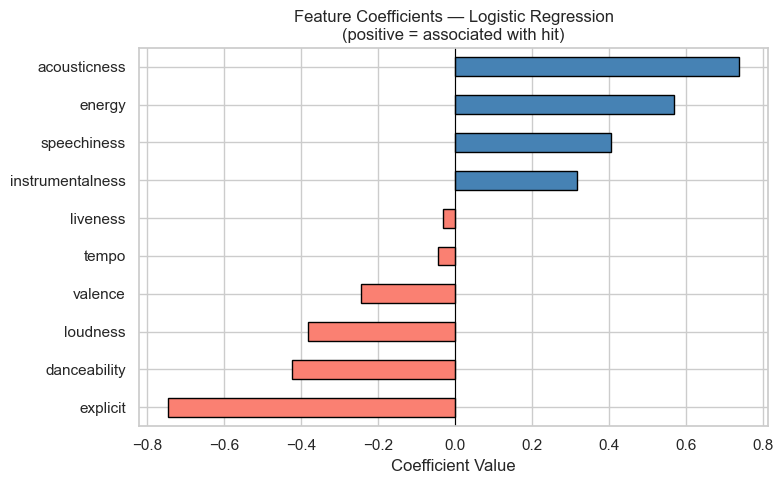

In [14]:
coef_df = pd.Series(lr.coef_[0], index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
coef_df.plot(kind='barh',
             color=['salmon' if c < 0 else 'steelblue' for c in coef_df],
             edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Logistic Regression\n(positive = associated with hit)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [15]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 3),
        round(accuracy_score(y_test, y_pred_dt), 3)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr), 3),
        round(precision_score(y_test, y_pred_dt), 3)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr), 3),
        round(recall_score(y_test, y_pred_dt), 3)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_dt), 3)
    ]
})

print('=== Final Model Performance Summary ===')
print(summary.to_string(index=False))
print()
print('Dataset: 1,000 hip-hop tracks from Kaggle Spotify Dataset')
print(f'Hit threshold: popularity >= {POPULARITY_THRESHOLD}')
print('Train/Test split: 80/20')
print(f'Hit rate in dataset: {df["is_hit"].mean():.1%}')


=== Final Model Performance Summary ===
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.685      0.692   0.807     0.745
      Decision Tree     0.770      0.821   0.763     0.791

Dataset: 1,000 hip-hop tracks from Kaggle Spotify Dataset
Hit threshold: popularity >= 50
Train/Test split: 80/20
Hit rate in dataset: 57.2%
